In [38]:
import re
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def process_xml(input_file):
    # Read file content
    with open(input_file, 'r', encoding='utf-8') as file:
        data = file.read()

    # Remove CDATA sections
    clean_data = re.sub(r'<!\[CDATA\[(.*?)\]\]>', r'\1', data, flags=re.DOTALL)

    # Parse XML from cleaned string
    root = ET.ElementTree(ET.fromstring(clean_data)).getroot()

    # Remove first two <chunk> elements
    chunks = root.findall(".//chunk")
    for i in range(min(2, len(chunks))):
        parent = chunks[i].getparent() if hasattr(chunks[i], "getparent") else root
        parent.remove(chunks[i])

    # Extract <pose> elements
    poses = [pose.text.strip().split(' ')[:2] for pose in root.findall(".//pose")]
    poses = np.array([[float(pose[0]), float(pose[1])] for pose in poses])
    return poses

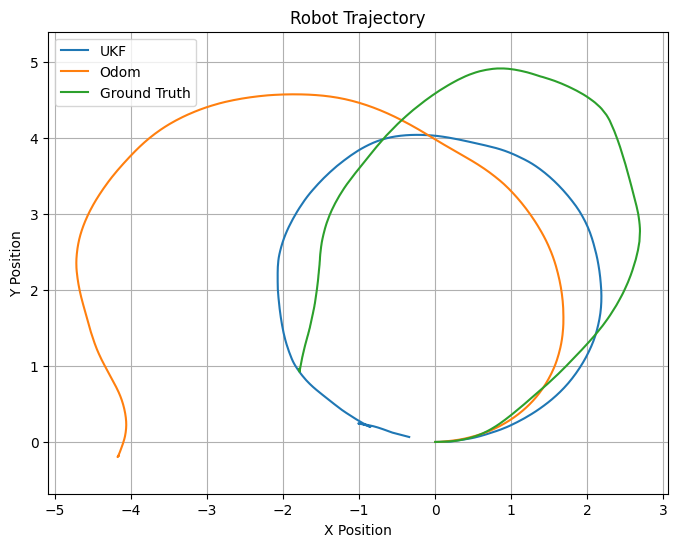

In [ ]:
def plot_trajectory(gazebo_poses):
    # Load the CSV file
    # raw_df = pd.read_csv('RAW_robot_pose.csv')
    # ekf_df = pd.read_csv('csv/EKF_robot_pose.csv')
    ukf_df = pd.read_csv('csv/UKF_robot_pose.csv')
    odom_df = pd.read_csv('csv/odom.csv')
    
    # Extract x and y coordinates
    # raw_x = raw_df['x']
    # raw_y = raw_df['y']

    # ekf_x = ekf_df['x']
    # ekf_y = ekf_df['y']

    ukf_x = ukf_df['x']
    ukf_y = ukf_df['y']

    odom_x = odom_df['x']
    odom_y = odom_df['y']
    
    # Plot the trajectory
    plt.figure(figsize=(8, 6))
    # plt.plot(raw_x, raw_y, label='Raw')
    # plt.plot(ekf_x, ekf_y, label='EKF')
    plt.plot(ukf_x, ukf_y, label='UKF')
    plt.plot(odom_x, odom_y, label='Odom')
    # plt.plot(gazebo_poses[:, 0], gazebo_poses[:, 1], label='Ground Truth')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Robot Trajectory')
    plt.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()

poses = process_xml("gazebo_data/raw_1.xml")
plot_trajectory(poses)